# Task 2.1 — Dataset Selection and Setup

Selected Paper: Learning Kernels with Radiuses of Minimum Enclosing Balls (NeurIPS 2010)

---

## Dataset Selection

The dataset is generated using `sklearn.datasets.make_classification` to create a controlled synthetic binary classification problem. It contains 500 samples and 5 features, of which 3 are informative. The task is binary classification, matching the supervised learning setting in the reference paper. This dataset is suitable for kernel methods because the informative features may exhibit nonlinear relationships that linear classifiers cannot capture effectively. Compared to the paper's datasets (e.g., UCI benchmarks), this dataset is smaller and simpler but still allows clear demonstration of kernel behavior and the effect of kernel learning.

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Create output directory if it doesn't exist
os.makedirs("results", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [42]:
# Generate synthetic dataset
X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.0,
    flip_y=0.05,
    random_state=42
)

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Class distribution: {np.bincount(y)}")

Feature matrix shape: (500, 5)
Label vector shape: (500,)
Class distribution: [246 254]


### Parameter Choices

- **`class_sep=1.0`** introduces moderate overlap between the two classes, making the problem harder than a well-separated dataset.
- **`flip_y=0.05`** randomly flips 5% of the labels to simulate label noise, as encountered in real-world datasets.
- Together, these settings produce a more realistic classification problem where kernel choice affects performance more noticeably — a linear classifier may struggle with the overlap and noise, while a well-chosen kernel can still find a good decision boundary.

## Dataset Explanation

The generated dataset is a synthetic binary classification problem with 500 samples and 5 features, where 3 features carry discriminative information. The remaining 2 features are random noise, making the classification task nontrivial.

This dataset is appropriate for kernel SVM experiments because the nonlinear separability controlled by `class_sep` and the cluster structure means kernel methods (such as RBF or polynomial kernels) can potentially find better decision boundaries than linear classifiers. This mirrors the motivation of the reference paper, which proposes learning optimal kernel combinations to improve classification in settings where single kernels or linear methods fall short.

In [43]:
# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set:     X_test={X_test.shape}, y_test={y_test.shape}")

Training set: X_train=(400, 5), y_train=(400,)
Test set:     X_test=(100, 5), y_test=(100,)


The data is split into 80% training (400 samples) and 20% testing (100 samples) using a fixed random state for reproducibility. The scaler will be fit only on training data to avoid data leakage.

In [44]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Scaled training set std:  {X_train_scaled.std(axis=0).round(4)}")

Scaled training set mean: [ 0.  0.  0.  0. -0.]
Scaled training set std:  [1. 1. 1. 1. 1.]


Feature scaling is applied using `StandardScaler` so that each feature has zero mean and unit variance. This is important for kernel methods because kernel computations (e.g., RBF kernel) are sensitive to feature magnitudes — unscaled features can dominate the kernel values and distort the decision boundary.

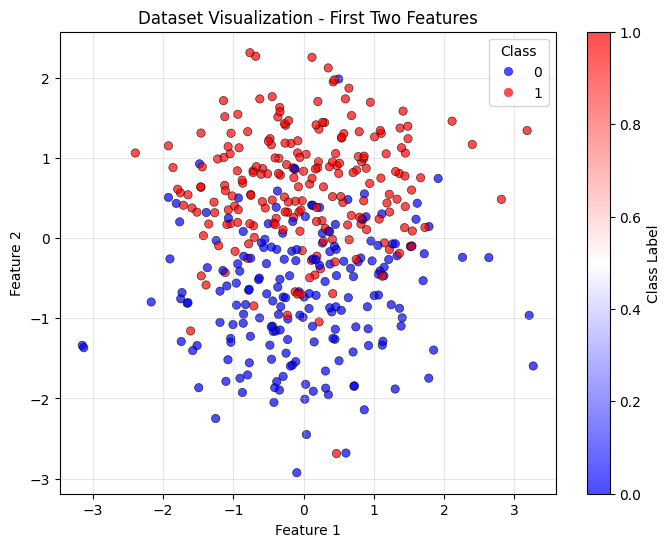

Figure saved to results/dataset_visualization.png


In [45]:
# Visualization: scatter plot of first two features
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1],
    c=y_train, cmap='bwr', alpha=0.7, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, label='Class Label')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset Visualization - First Two Features')
plt.legend(*scatter.legend_elements(), title='Class')
plt.grid(True, alpha=0.3)
plt.savefig('results/dataset_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/dataset_visualization.png")

## Visualization Explanation

The scatter plot shows the distribution of the two classes projected onto the first two feature dimensions of the scaled training data. Any visible overlap or nonlinear boundary between the classes suggests that a simple linear classifier may struggle to separate them cleanly.

Kernel methods address this by implicitly mapping the data into a higher-dimensional feature space where a separating hyperplane can be found. This is the core motivation behind the MEB-based kernel learning approach in the reference paper — by learning an optimal combination of kernels, the method constructs a feature space that maximizes class separability while accounting for the data's geometric spread via the Minimum Enclosing Ball radius.

## Dataset Justification

The dataset is a synthetic binary classification dataset generated using `sklearn.datasets.make_classification`, containing 500 samples and 5 features with moderate class overlap (`class_sep=1.0`) and 5% label noise (`flip_y=0.05`). It is well suited for evaluating kernel-based SVM classifiers because the nonlinear feature relationships and class overlap allow different kernels (linear, RBF, polynomial) to produce meaningfully different decision boundaries, making kernel choice a significant factor in classification performance. This directly mirrors the motivation of the reference paper, where kernel selection and combination are shown to affect generalization. Compared to the UCI benchmark datasets used in the original paper, this dataset is significantly smaller and simpler, lacking the high dimensionality and real-world noise patterns of those benchmarks — but it is sufficient to clearly demonstrate how kernel choice and kernel combination influence classification accuracy.